---
title: "Supervised Learning"
format:
    html: 
        code-fold: false
---

# Introduction and Motivation
This section evaluates three closely related tasks. 

First, it examines whether a binary classification model can serve as an early warning system for power ramp events. 

Second, it explores whether these events can be further distinguished by direction, separating upward and downward ramps.
 
Finally, it assesses how well wind power output itself can be predicted under real operating conditions. Together, these analyses aim to determine whether monitoring instability provides more practical value for grid operations than relying on traditional point forecasts.

# Overview of methods

### Binary Classification 

- **Objective:** Predict whether a time interval corresponds to a power ramp event or stable operation.
- **Model:** Gradient Boosting classifier.
- **Inputs:** Meteorological variables (wind speed and volatility measures) and recent power information.
- **Output:** Binary label indicating ramp or non-ramp conditions.
- **Key Settings:** Number of trees, learning rate, and maximum tree depth.

### Multi-class Classification

- **Objective:** Distinguish among stable operation, upward ramps, and downward ramps.
- **Model:** Gradient Boosting classifier (multi-class extension).
- **Inputs:** Same feature set as the binary classification task.
- **Output:** Categorical label representing the direction of power change.

### Regression Analysis

- **Objective:** Predict continuous wind power output.
- **Models:**
  - Linear Regression as a baseline model.
  - Random Forest Regression as a non-linear alternative.
- **Inputs:** Meteorological variables and derived features.
- **Output:** Predicted power output (MW).
- **Key Settings:** Number of trees and maximum tree depth for Random Forest.

### Model Evaluation Setup

- **Data Split:** Training and testing subsets are used for all models.
- **Purpose:** Ensure consistent evaluation of generalization performance across tasks.

# Code 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

### Binary Classification

Loading data...
Data shape: (388654, 3)
Target distribution:
Is_Ramp
0    0.949997
1    0.050003
Name: proportion, dtype: float64


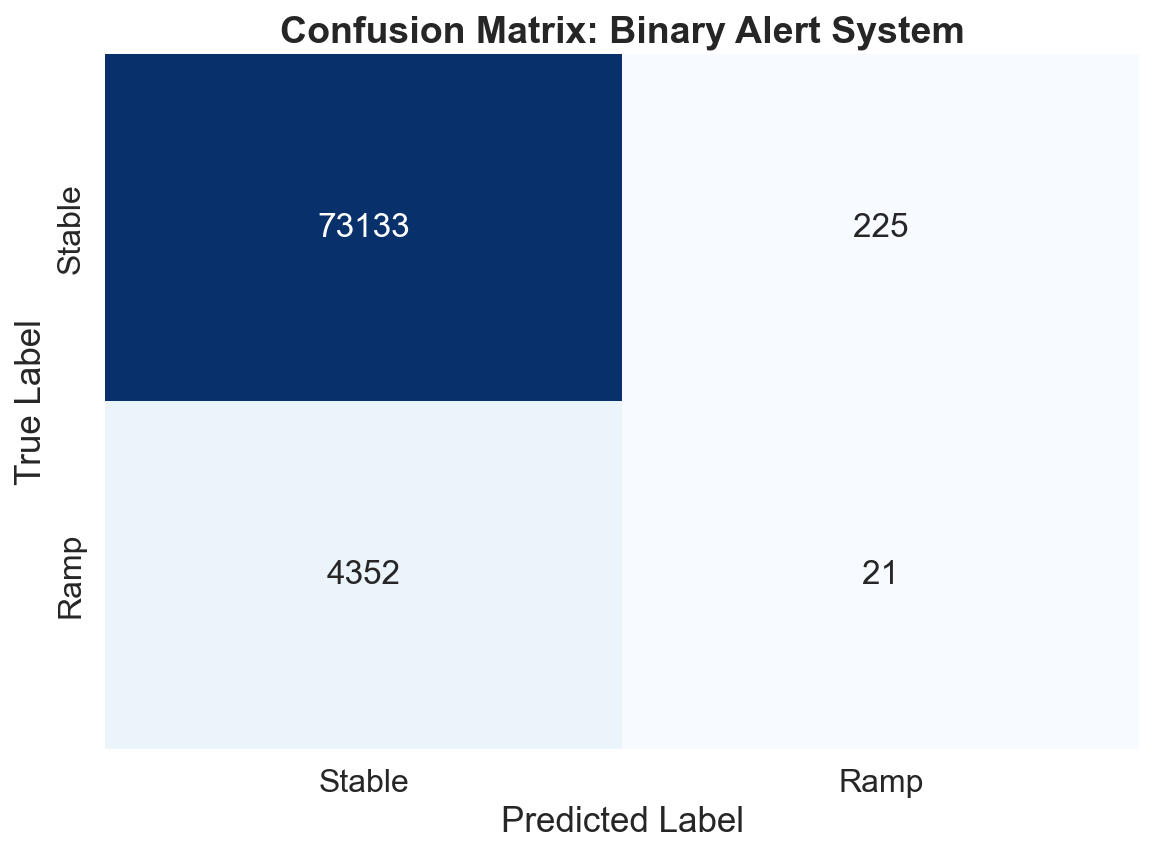


Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     73358
           1       0.09      0.00      0.01      4373

    accuracy                           0.94     77731
   macro avg       0.51      0.50      0.49     77731
weighted avg       0.90      0.94      0.92     77731

ROC-AUC: 0.7171


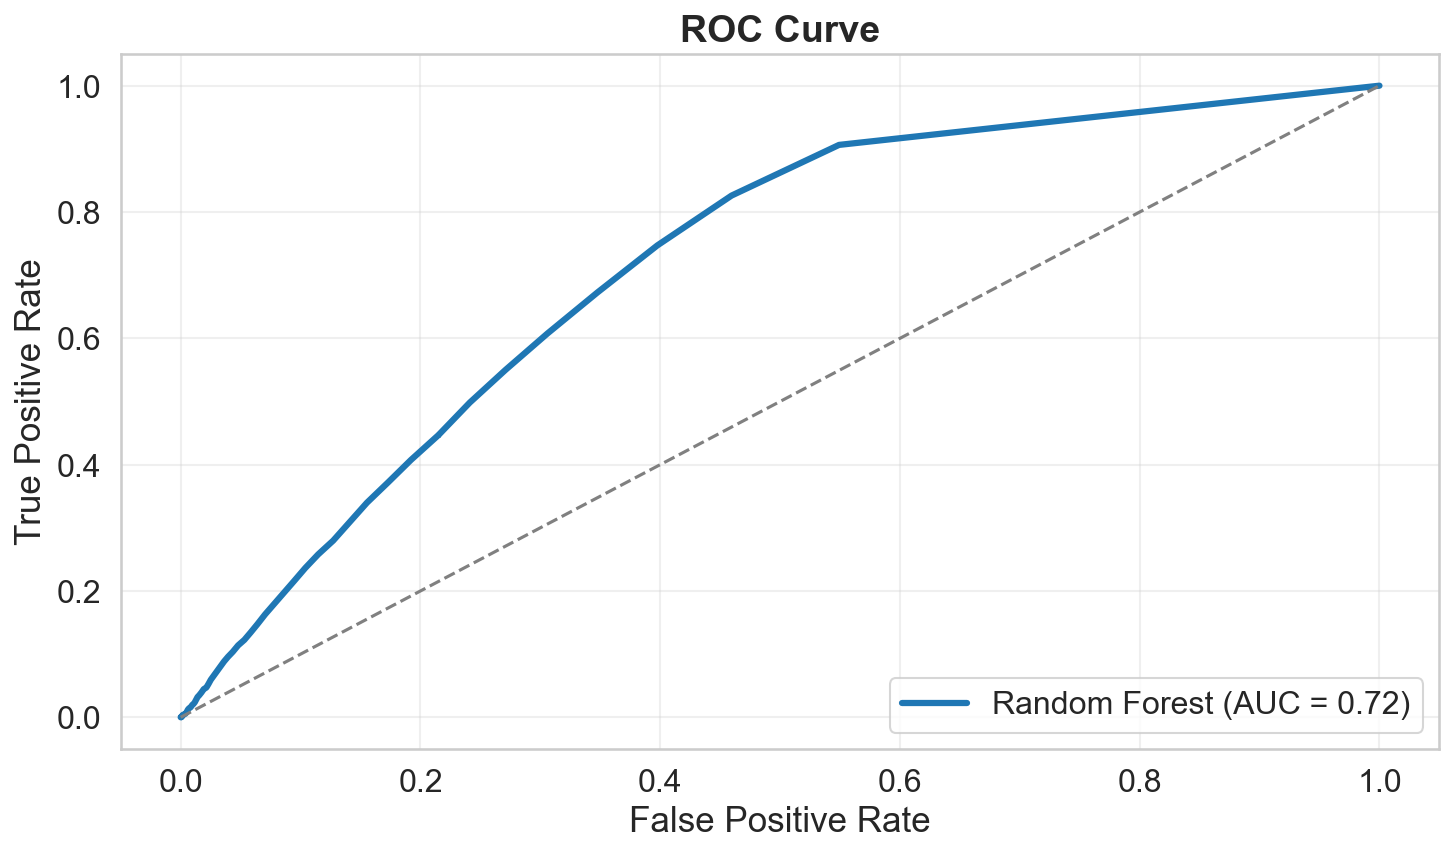

/var/folders/6f/mpj7nyk15wx2xll23dsk4zk80000gn/T/ipykernel_82327/3949767313.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


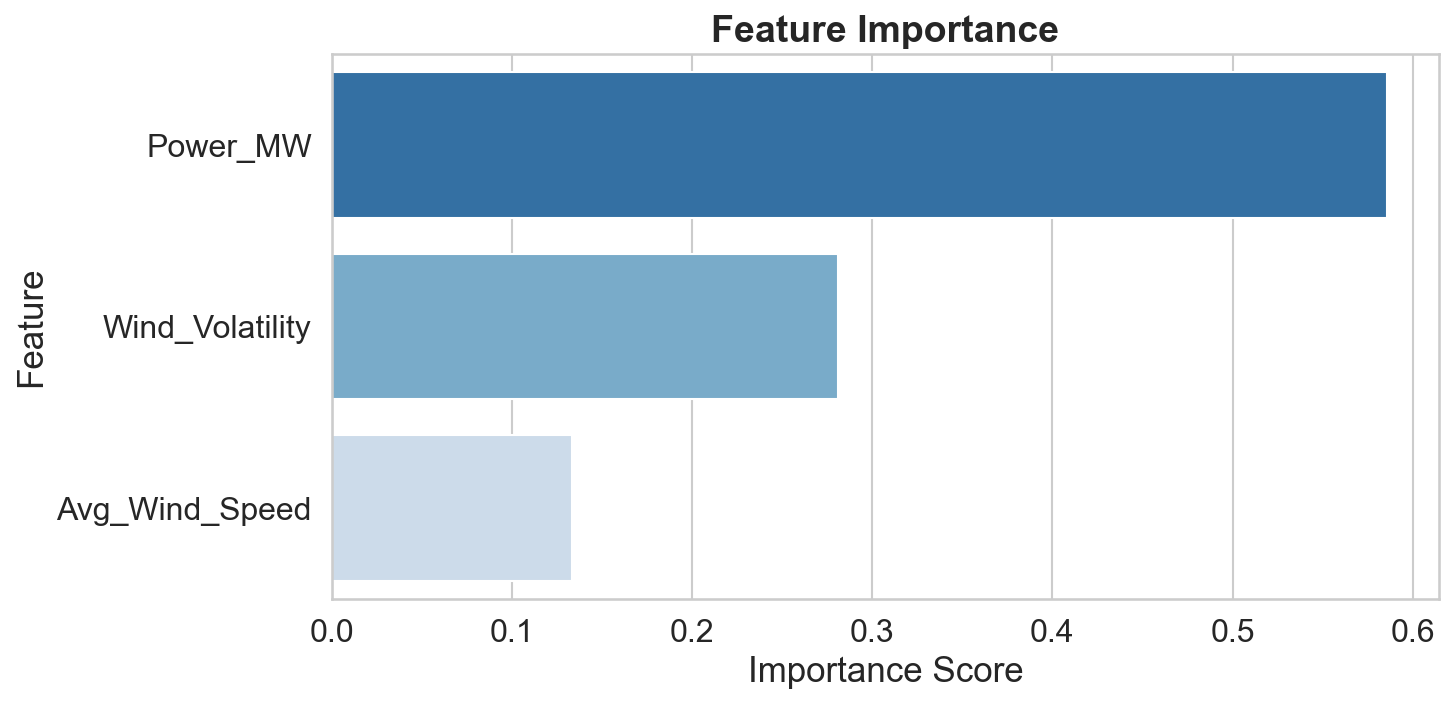


Top predictors:
            Feature  Importance
2         Power_MW    0.585476
1  Wind_Volatility    0.281224
0   Avg_Wind_Speed    0.133299


In [9]:
# Plot style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.4)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150

custom_colors = ["#1f77b4", "#E63946"]

# Load data
print("Loading data...")
df = pd.read_csv("../../data/processed-data/BPA_EDA_Enhanced.csv")

if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.set_index("Timestamp").sort_index()

# Feature set (avoid leakage)
features = ["Avg_Wind_Speed", "Wind_Volatility", "Power_MW"]
target = "Is_Ramp"

if target not in df.columns:
    df[target] = np.where(df["Power_MW"].diff().abs() > 100, 1, 0)

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

print(f"Data shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# Time-based train/test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16})
plt.title("Confusion Matrix: Binary Alert System", fontsize=18, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5, 1.5], ["Stable", "Ramp"])
plt.yticks([0.5, 1.5], ["Stable", "Ramp"])
plt.tight_layout()
plt.show()

# Metrics
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, lw=3, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.title("ROC Curve", fontsize=18, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": rf_model.feature_importances_,
    })
    .sort_values(by="Importance", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="Blues_r",
)
plt.title("Feature Importance", fontsize=18, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nTop predictors:\n", feature_importance)


### Multi Classification

--- 1. Loading Data ---
Data Loaded. Shape: (388654, 3)
Features Used: ['Avg_Wind_Speed', 'Wind_Volatility', 'Power_MW']
Target Distribution:
Is_Ramp
0    0.949997
1    0.050003
Name: proportion, dtype: float64

--- 2. Splitting Data (80/20) ---
Train size: 310923
Test size:  77731

--- 3. Training Gradient Boosting (Imbalance-Aware) ---


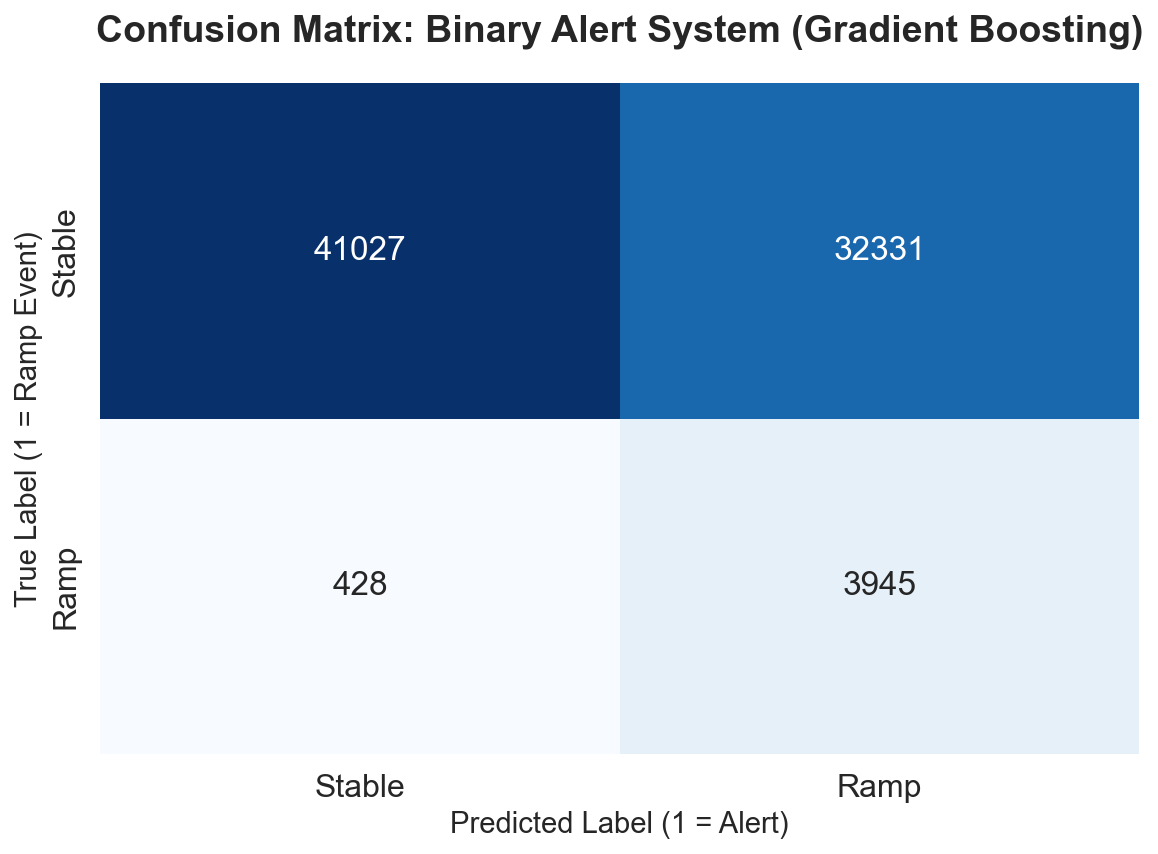


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.56      0.71     73358
           1       0.11      0.90      0.19      4373

    accuracy                           0.58     77731
   macro avg       0.55      0.73      0.45     77731
weighted avg       0.94      0.58      0.69     77731

ROC-AUC Score: 0.7862


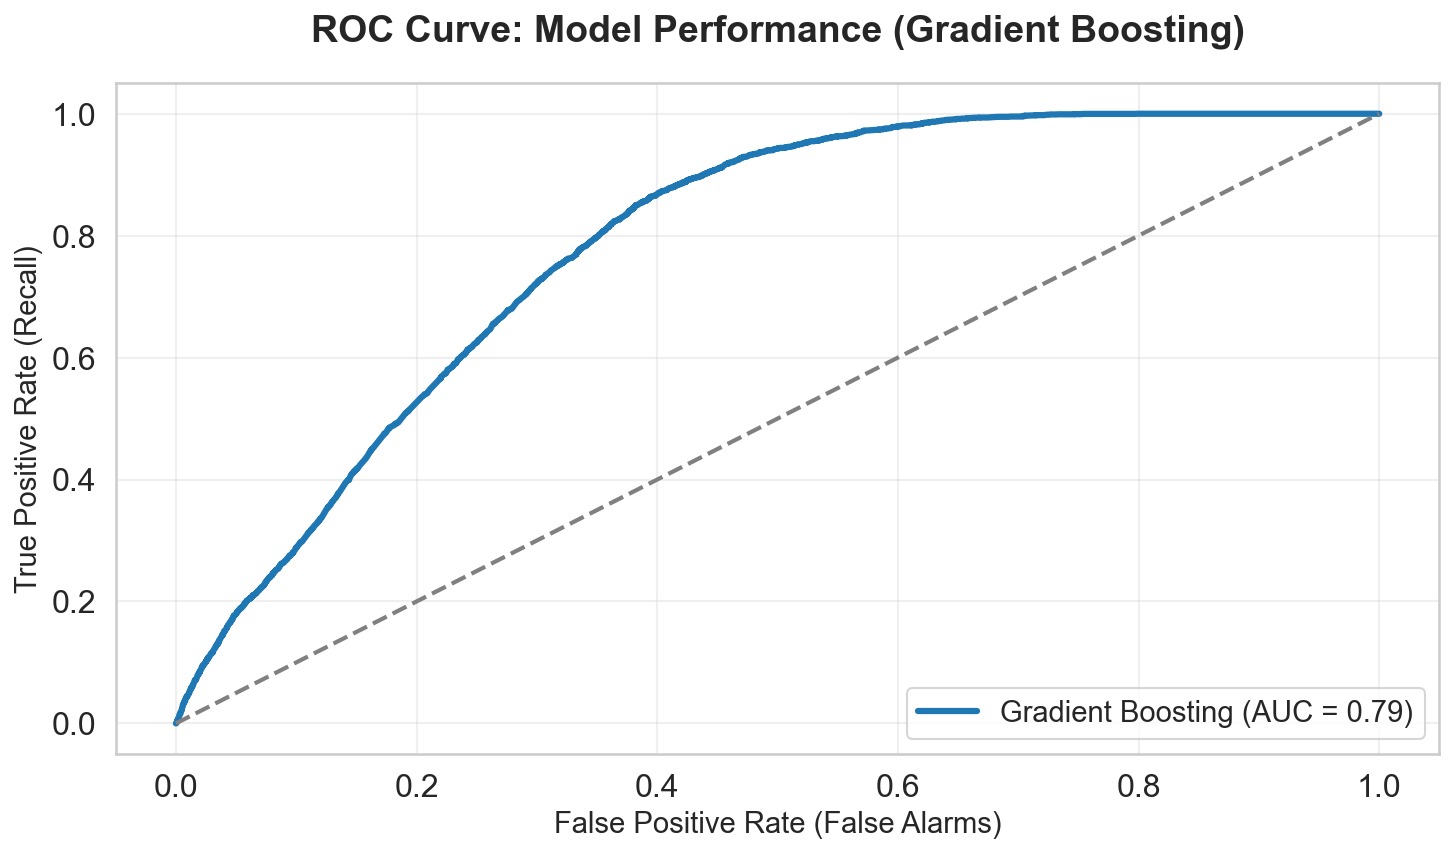

/var/folders/6f/mpj7nyk15wx2xll23dsk4zk80000gn/T/ipykernel_82327/823005553.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="Blues_r")


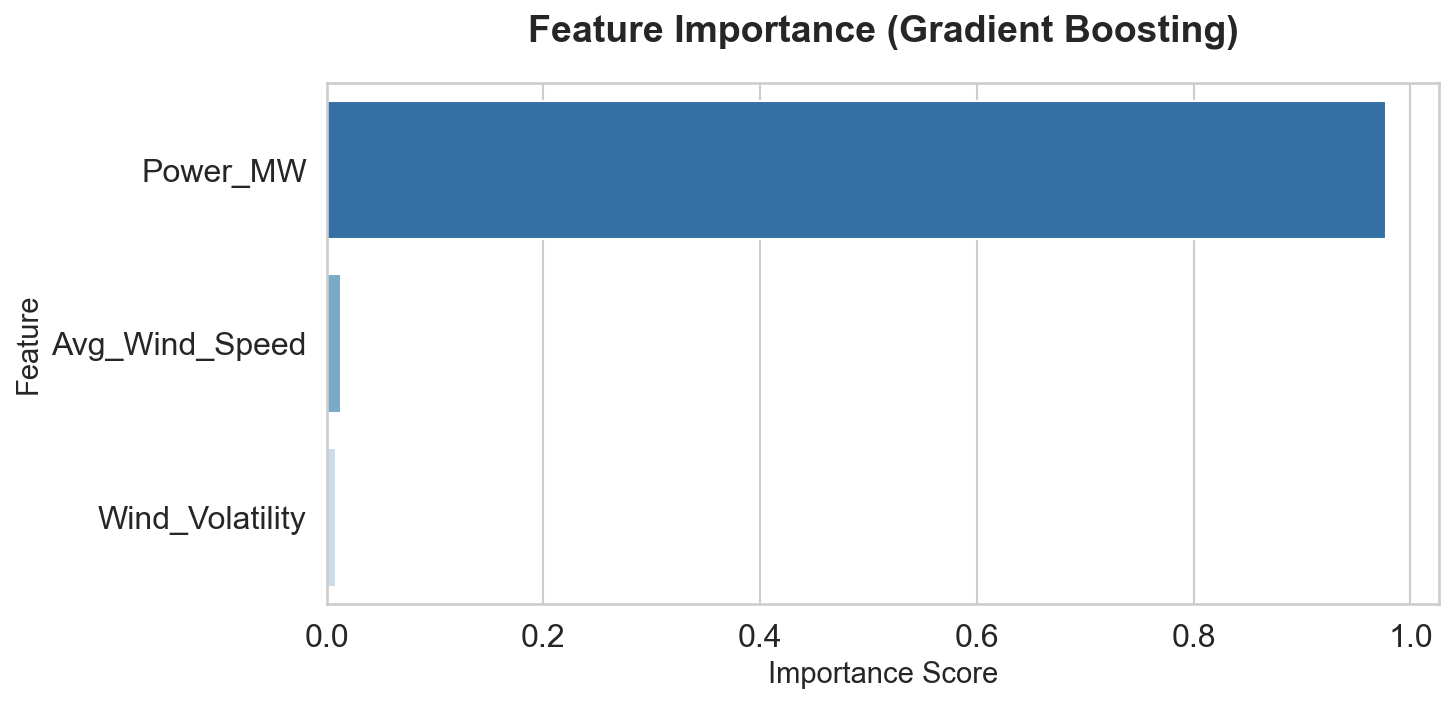


Top Predictors:
            Feature  Importance
2         Power_MW    0.977853
0   Avg_Wind_Speed    0.013614
1  Wind_Volatility    0.008533


In [13]:
# ==========================================
# 0. Global plotting style
# ==========================================
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.4)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150

custom_colors = ["#1f77b4", "#E63946"]  # Stable vs Alert

# ==========================================
# 1. Load data & features
# ==========================================
print("--- 1. Loading Data ---")
df = pd.read_csv("../../data/processed-data/BPA_EDA_Enhanced.csv")

if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.set_index("Timestamp").sort_index()

features = ["Avg_Wind_Speed", "Wind_Volatility", "Power_MW"]
target = "Is_Ramp"

if target not in df.columns:
    df[target] = np.where(df["Power_MW"].diff().abs() > 100, 1, 0)

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

print(f"Data Loaded. Shape: {X.shape}")
print(f"Features Used: {features}")
print(f"Target Distribution:\n{y.value_counts(normalize=True)}")

# ==========================================
# 2. Time-based split (80/20)
# ==========================================
print("\n--- 2. Splitting Data (80/20) ---")
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Train Gradient Boosting (with sample weights)
# ==========================================
print("\n--- 3. Training Gradient Boosting (Imbalance-Aware) ---")

# Handles imbalance since GradientBoostingClassifier has no class_weight
sample_w = compute_sample_weight(class_weight="balanced", y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train, sample_weight=sample_w)

y_pred = gb_model.predict(X_test_scaled)
y_prob = gb_model.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# 4. Evaluation & plots
# ==========================================

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16})
plt.title("Confusion Matrix: Binary Alert System (Gradient Boosting)", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Predicted Label (1 = Alert)", fontsize=14)
plt.ylabel("True Label (1 = Ramp Event)", fontsize=14)
plt.xticks([0.5, 1.5], ["Stable", "Ramp"])
plt.yticks([0.5, 1.5], ["Stable", "Ramp"])
plt.tight_layout()
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, lw=3, label=f"Gradient Boosting (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--", color="grey")
plt.title("ROC Curve: Model Performance (Gradient Boosting)", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("False Positive Rate (False Alarms)", fontsize=14)
plt.ylabel("True Positive Rate (Recall)", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="Blues_r")
plt.title("Feature Importance (Gradient Boosting)", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()print("\nTop Predictors:\n", feature_importance)


Loading data for regression...
Regression data shape: (388654, 2)
Training Linear Regression...
Linear Regression -> R2: 0.0966 | RMSE: 753.69 MW
Training Random Forest...
Random Forest     -> R2: 0.0961 | RMSE: 753.87 MW
Visualizing predictions...


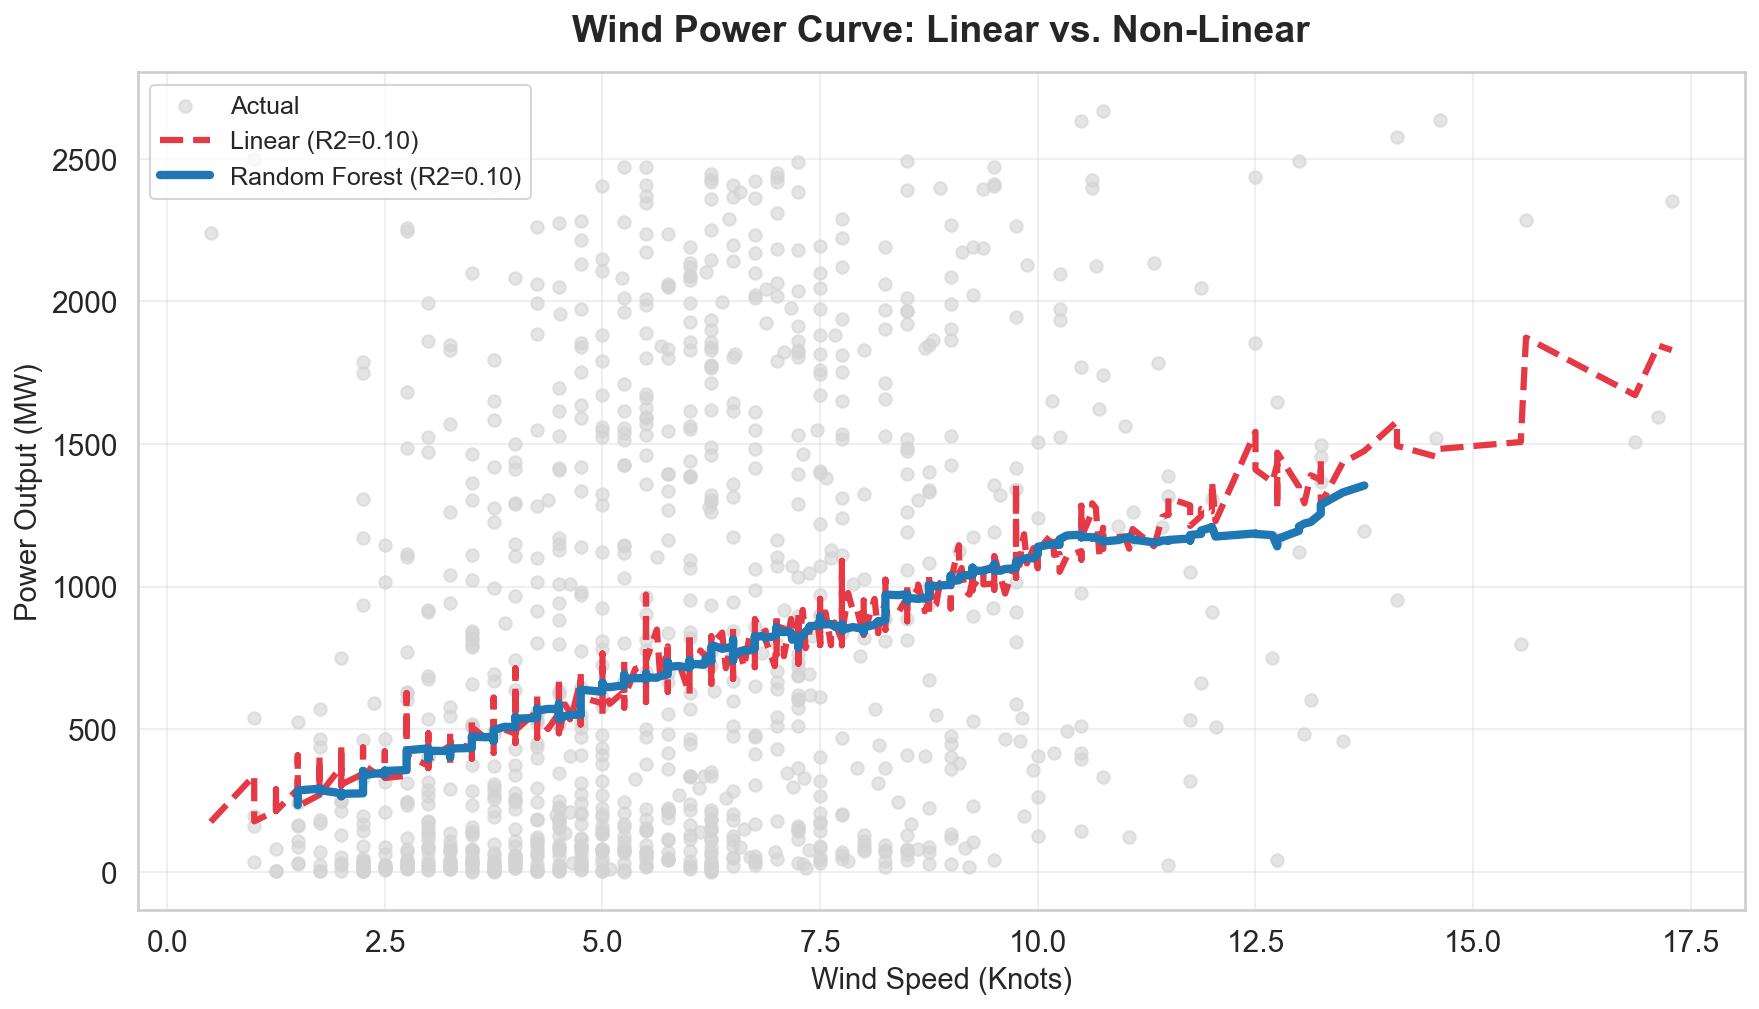

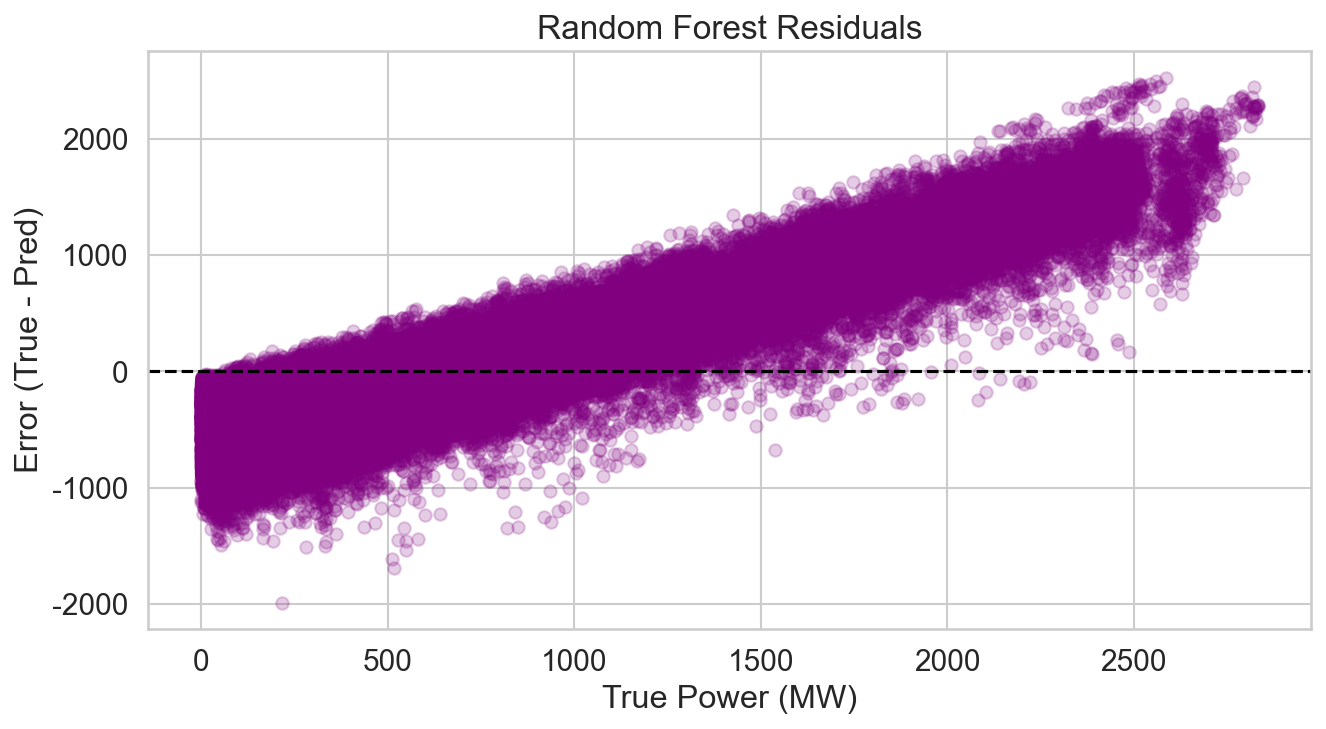

Max underprediction: 2524.92 MW
Max overprediction:  -1986.55 MW


In [11]:


# Plot style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150

# Load data
print("Loading data for regression...")
try:
    df = pd.read_csv("BPA_EDA_Enhanced.csv")
except:
    df = pd.read_csv("../../data/processed-data/BPA_EDA_Enhanced.csv")

if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.set_index("Timestamp").sort_index()

# Features and target
features = ["Avg_Wind_Speed", "Wind_Volatility"]
target = "Power_MW"

df_reg = df[features + [target]].dropna()
X = df_reg[features]
y = df_reg[target]
print(f"Regression data shape: {X.shape}")

# Time-based split + scaling
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression -> R2: {r2_lr:.4f} | RMSE: {rmse_lr:.2f} MW")

# Model 2: Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest     -> R2: {r2_rf:.4f} | RMSE: {rmse_rf:.2f} MW")

# S-curve comparison plot
print("Visualizing predictions...")
viz_df = pd.DataFrame({
    "Wind_Speed": X_test["Avg_Wind_Speed"],
    "True_Power": y_test,
    "Linear_Pred": y_pred_lr,
    "RF_Pred": y_pred_rf,
}).sample(n=1000, random_state=42).sort_values(by="Wind_Speed")

plt.figure(figsize=(12, 7))
plt.scatter(
    viz_df["Wind_Speed"],
    viz_df["True_Power"],
    color="lightgrey",
    alpha=0.6,
    label="Actual",
)
plt.plot(
    viz_df["Wind_Speed"],
    viz_df["Linear_Pred"],
    color="#E63946",
    linewidth=3,
    linestyle="--",
    label=f"Linear (R2={r2_lr:.2f})",
)
plt.plot(
    viz_df["Wind_Speed"],
    viz_df["RF_Pred"].rolling(window=20, center=True).mean(),
    color="#1f77b4",
    linewidth=4,
    label=f"Random Forest (R2={r2_rf:.2f})",
)

plt.title("Wind Power Curve: Linear vs. Non-Linear", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Wind Speed (Knots)", fontsize=14)
plt.ylabel("Power Output (MW)", fontsize=14)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual diagnostics (RF)
plt.figure(figsize=(10, 5))
residuals = y_test - y_pred_rf
plt.scatter(y_test, residuals, alpha=0.2, color="purple")
plt.axhline(0, color="black", linestyle="--")
plt.title("Random Forest Residuals", fontsize=16)
plt.xlabel("True Power (MW)")
plt.ylabel("Error (True - Pred)")
plt.show()

print(f"Max underprediction: {residuals.max():.2f} MW")
print(f"Max overprediction:  {residuals.min():.2f} MW")


# Summary and Interpretation of Results

**Binary classification results** show that it is possible to build an early-warning signal for wind power ramp events using atmospheric and power-related indicators. The model can broadly distinguish unstable conditions from normal operation, but it is highly conservative: it correctly recognizes stable periods most of the time while missing many rare ramp events. This highlights a key operational insight—models that appear accurate overall may still be unsafe if they fail to flag rare but high-impact risks. Importantly, the most influential signals are not absolute wind speed, but measures related to wind and power variability, supporting the idea that instability, rather than level, drives grid risk.

**Multi-class classification** further reveals the limits of predictive detail. While the model can separate stable operation from abnormal behavior, it struggles to reliably distinguish upward ramps from downward ramps. This suggests that identifying whether the system is becoming unstable is more feasible than predicting the exact direction of change. In practice, this supports treating ramp detection as a warning problem rather than a precise directional forecast.

**Regression analysis** confirms the gap between idealized physical theory and real-world wind power behavior. Neither linear nor non-linear models can accurately reconstruct the full wind power curve from meteorological inputs alone. Prediction errors increase at higher power levels, reflecting the influence of turbine controls, grid constraints, and other unobserved operational factors. These results indicate that precise point forecasting is inherently difficult under real operating conditions.
